In [ ]:
import warnings

# Suppress FutureWarning from pandas
warnings.filterwarnings('ignore', category=FutureWarning, module='dice_ml')

# Suppress UserWarning from sklearn about feature names
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn.utils.validation')

In [ ]:
import pandas as pd
import numpy as np

import plotly.express as px
import plotly.graph_objects as go

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.feature_selection import mutual_info_classif
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold

from sklearn.ensemble import RandomForestClassifier

# from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# from xgboost import XGBClassifier
# from lightgbm import LGBMClassifier

from sklearn.linear_model import LogisticRegression
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
# from sklearn.svm import SVC
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

from imblearn.over_sampling import SMOTENC
from collections import Counter

# import torch
# import torch.nn as nn
# import torch.optim as optim
# from torch.utils.data import Dataset, DataLoader

In [ ]:
file_path = '/content/Employee attrition dataset for non-tree-based models.xlsx'
df = pd.read_excel(file_path)

print("DataFrame loaded successfully. First 5 rows:")
display(df.head())

DataFrame loaded successfully. First 5 rows:


,Attrition,Gender,Age,Academic_degree,Years_Experience,Years_experience_lastorganization,JobTitle,MonthlySalary,Allowances,MedicalInsurance,...,Sector_Food,Sector_Medical,Sector_Other,Department_Administration,Department_Customer Service,Department_Other,Department_Patient Affairs,Department_Processes,Department_Sales,Department_Teaching
0,1,0,1,2,0,0,0.623277,1,2,0,...,0,1,0,0,0,0,0,0,0,0
1,0,0,0,2,0,0,0.623277,2,2,1,...,0,1,0,0,0,0,0,0,0,0
2,0,0,0,1,0,0,0.190450,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,0,0,0,1,0,0,0.190450,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,0,0,0,1,0,0,0.190450,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [ ]:
df = df[df['Sector_Medical'] == 1]

print("DataFrame filtered. First 5 rows where Sector_Medical is 1:")
display(df.shape)

DataFrame filtered. First 5 rows where Sector_Medical is 1:


(298, 44)

In [ ]:
columns_to_drop = [col for col in df.columns if 'Sector' in col]
df = df.drop(columns=columns_to_drop)

print(f"Dropped {len(columns_to_drop)} columns containing 'Sector'.")
display(df.shape)

Dropped 4 columns containing 'Sector'.


(298, 40)

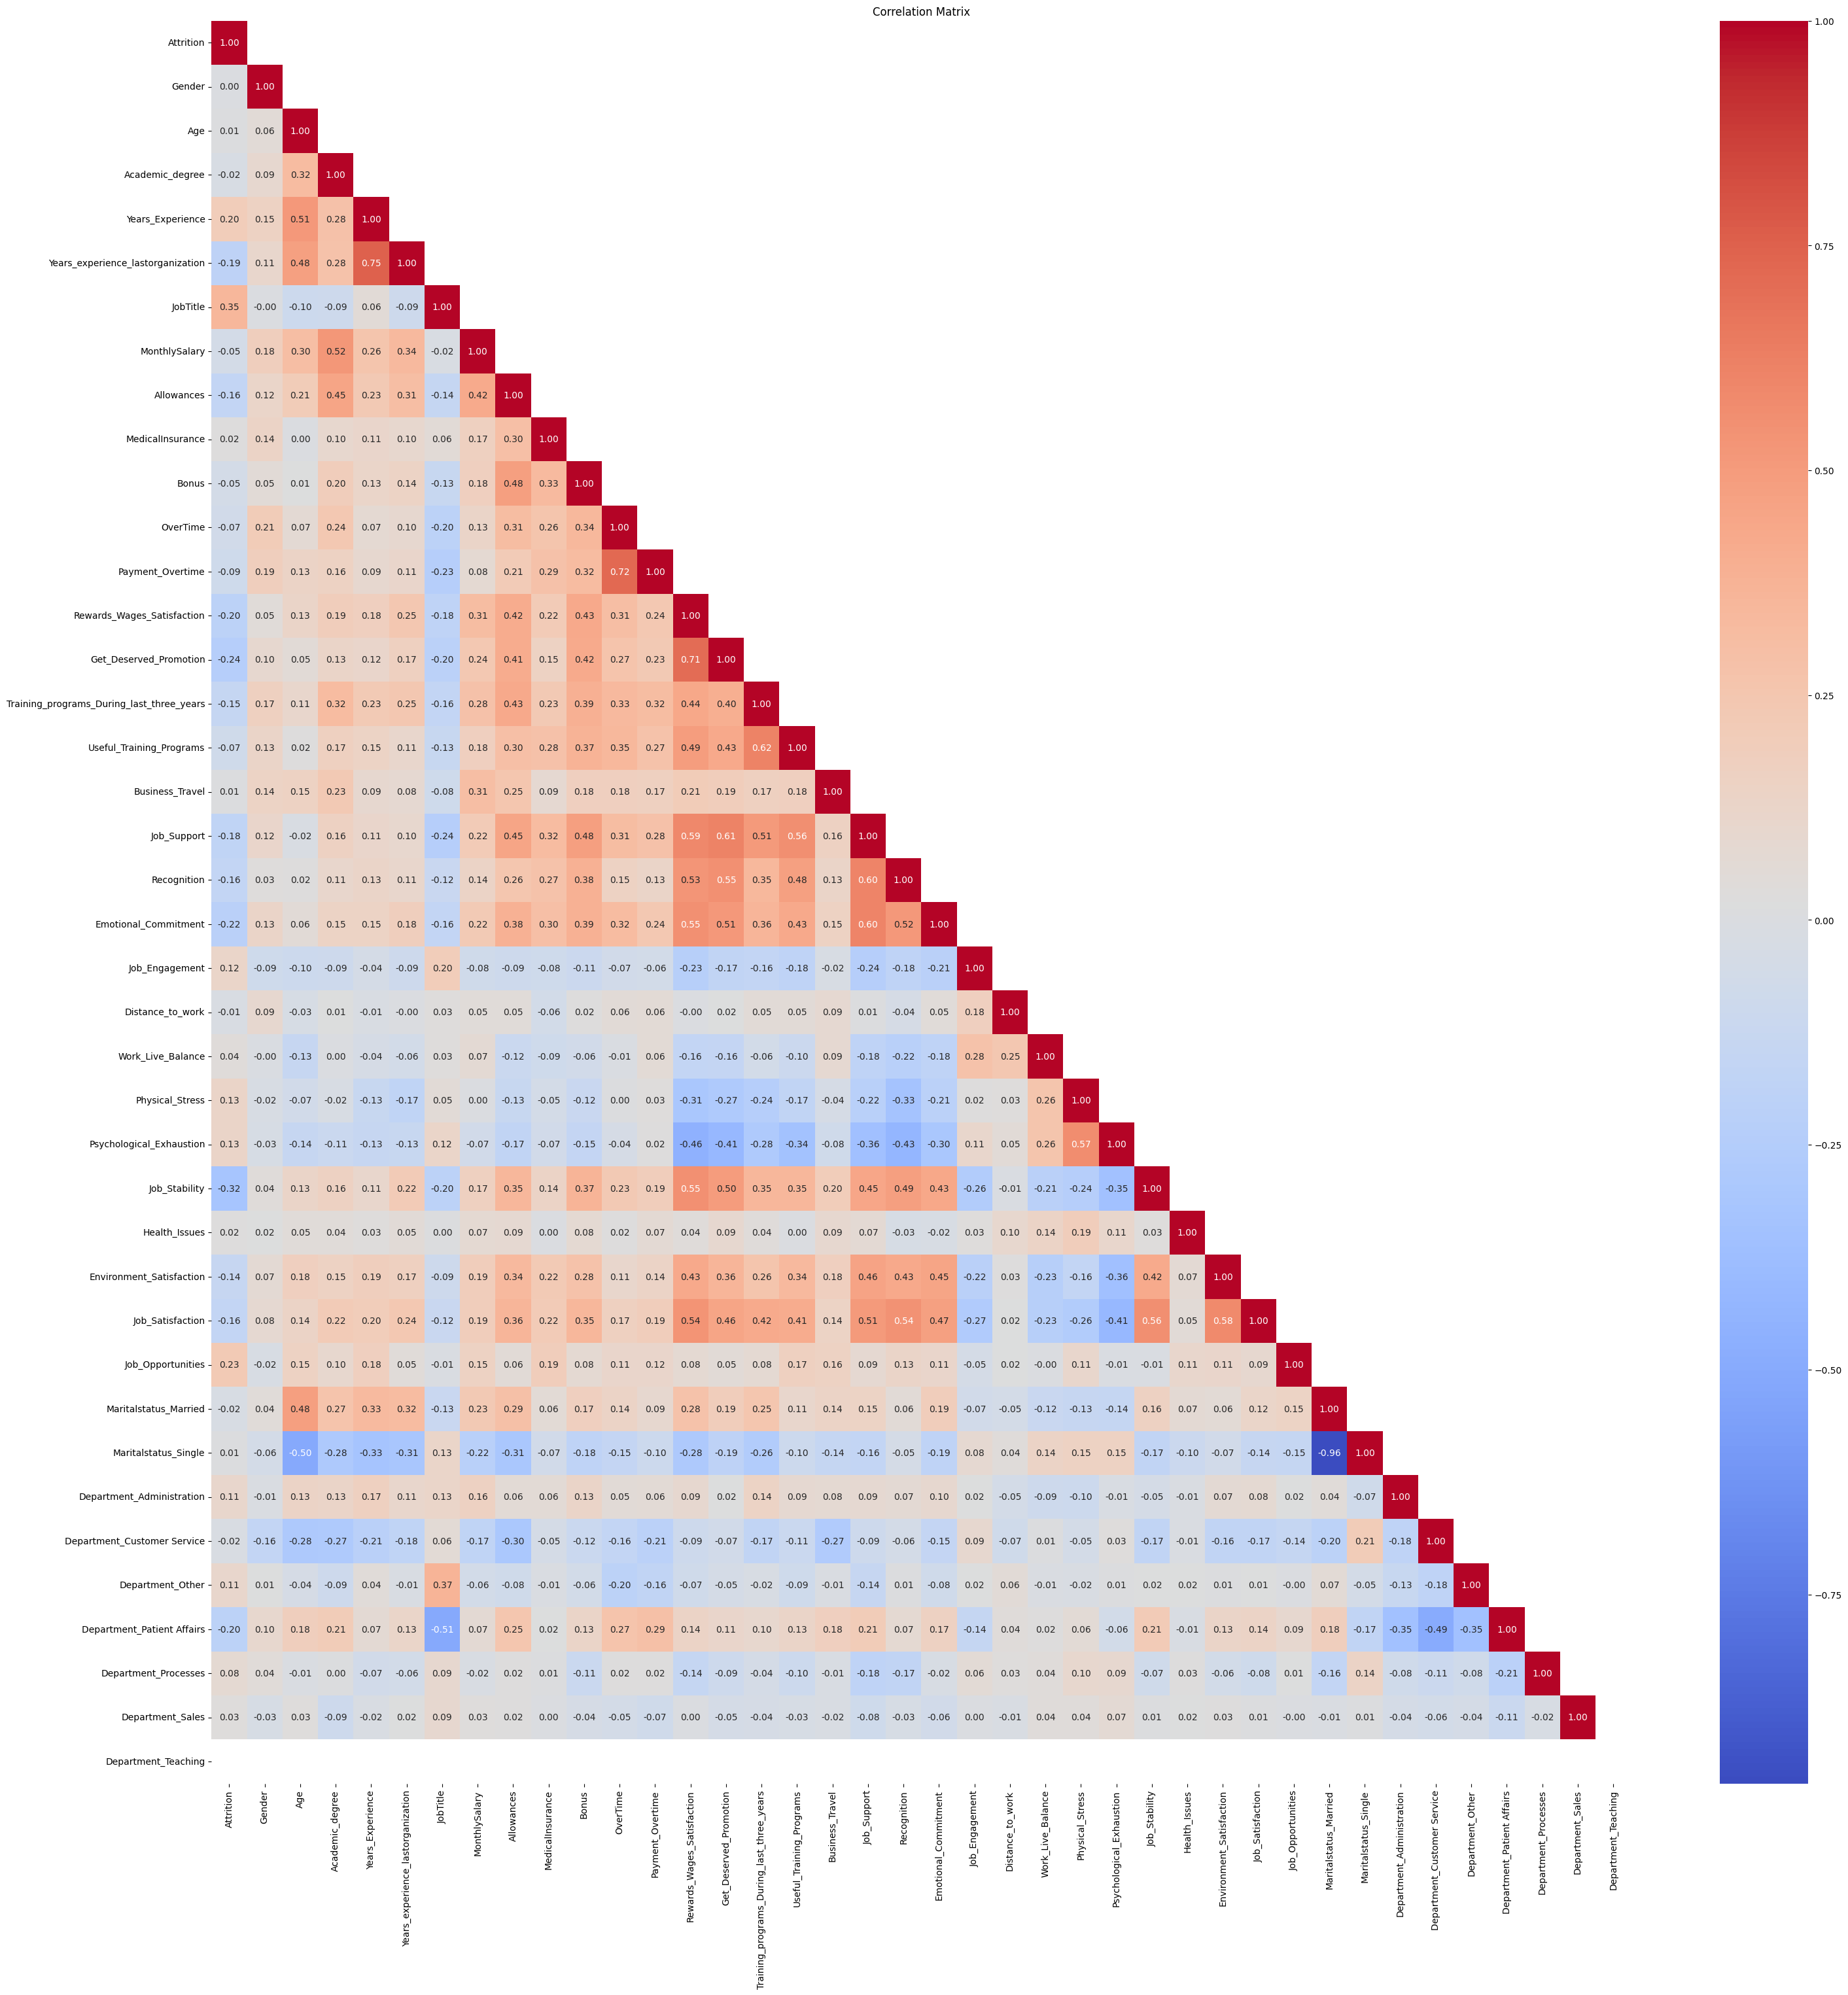

In [ ]:
def calculate_correlation_matrix(df):
  # Calculate the correlation matrix
  corr_matrix = df.corr()

  # Generate a mask for the upper triangle
  mask = corr_matrix.mask(np.triu(np.ones_like(corr_matrix), k=1).astype(bool))

  # Plot the heatmap
  plt.figure(figsize=(35, 35))
  sns.heatmap(mask, annot=True, cmap='coolwarm', fmt=".2f")
  plt.title('Correlation Matrix')
  plt.show()

calculate_correlation_matrix(df)

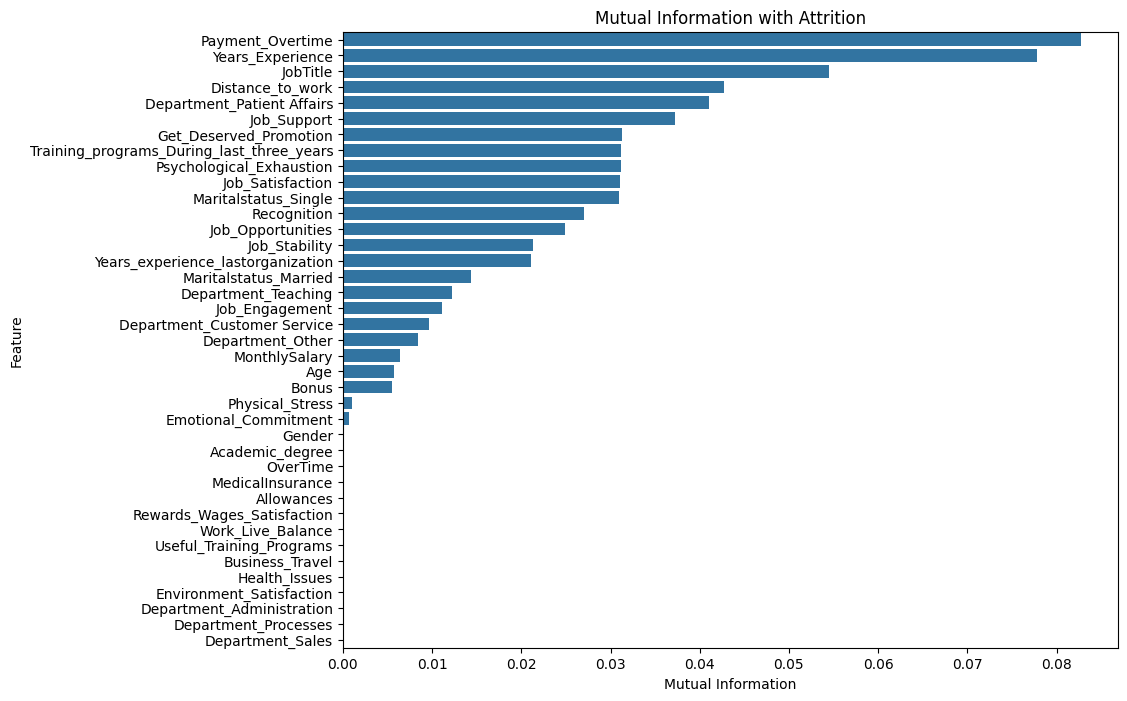

Columns with zero mutual information:
['Gender', 'Academic_degree', 'OverTime', 'MedicalInsurance', 'Allowances', 'Rewards_Wages_Satisfaction', 'Work_Live_Balance', 'Useful_Training_Programs', 'Business_Travel', 'Health_Issues', 'Environment_Satisfaction', 'Department_Administration', 'Department_Processes', 'Department_Sales']


In [ ]:
def calculate_mutual_information(df):
  # Separate features and target
  X = df.drop('Attrition', axis=1)
  y = df['Attrition']

  # Calculate mutual information
  mutual_info = mutual_info_classif(X, y, random_state=111)

  # Create a DataFrame to visualize the results
  mutual_info_df = pd.DataFrame({'Feature': X.columns, 'Mutual Information': mutual_info})
  mutual_info_df = mutual_info_df.sort_values(by='Mutual Information', ascending=False)

  # Plot the mutual information scores
  plt.figure(figsize=(10, 8))
  sns.barplot(x='Mutual Information', y='Feature', data=mutual_info_df)
  plt.title('Mutual Information with Attrition')
  plt.show()
  return mutual_info_df

mutual_info_df = calculate_mutual_information(df)
zero_mi_features = mutual_info_df[mutual_info_df['Mutual Information'] == 0]['Feature'].tolist()
print("Columns with zero mutual information:")
print(zero_mi_features)

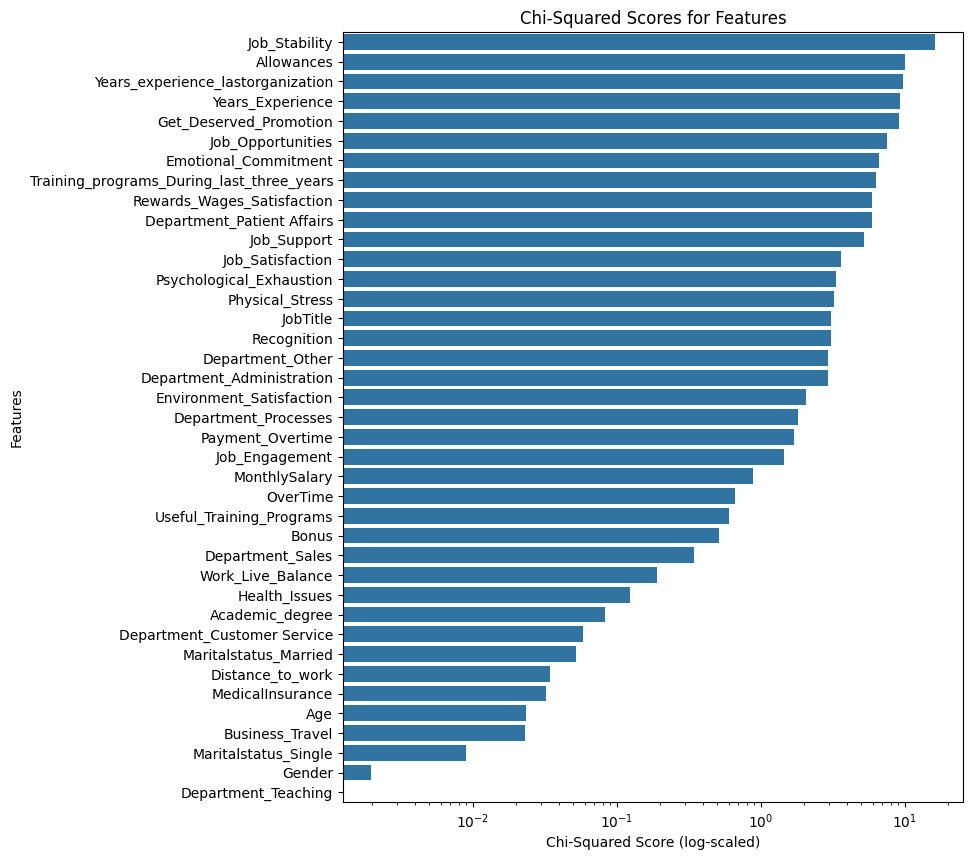

                        Feature  Chi-Square Score   p-value
0                        Gender          0.001974  0.964566
1                           Age          0.023543  0.878053
2               Academic_degree          0.083423  0.772711
8              MedicalInsurance          0.032501  0.856933
16              Business_Travel          0.023235  0.878847
21             Distance_to_work          0.034499  0.852649
22            Work_Live_Balance          0.190988  0.662095
26                Health_Issues          0.123776  0.724974
30        Maritalstatus_Married          0.052135  0.819389
31         Maritalstatus_Single          0.008934  0.924696
33  Department_Customer Service          0.058044  0.809615
37             Department_Sales          0.345256  0.556811


In [ ]:
def calculate_chi_squared(df):
  chi_squared_df = df

  # Separate features and target
  X = chi_squared_df.drop('Attrition', axis=1)
  y = chi_squared_df['Attrition']

  # Apply Chi-Square test
  chi2_selector = SelectKBest(chi2, k='all')  # Select all features based on Chi-Square scores
  X_kbest = chi2_selector.fit_transform(X, y)

  # Display Chi-Square scores for each feature
  chi2_scores = chi2_selector.scores_
  p_values = chi2_selector.pvalues_

  # Create a DataFrame to show the feature names, Chi-Square scores, and p-values
  results = pd.DataFrame({
      'Feature': X.columns,
      'Chi-Square Score': chi2_scores,
      'p-value': p_values
  })

  # Sort the results DataFrame by Chi-Square Score
  results_sorted = results.sort_values(by='Chi-Square Score', ascending=False)

  # Plot the Chi-Square scores
  plt.figure(figsize=(8, 10))
  #plt.bar(results_sorted['Feature'], results_sorted['Chi-Square Score'])
  sns.barplot(x=results_sorted['Chi-Square Score'], y=results_sorted['Feature'])
  plt.xlabel('Chi-Squared Score (log-scaled)')
  plt.ylabel('Features')
  plt.title('Chi-Squared Scores for Features')
  plt.xscale('log')  # Use logarithmic scale for better visualization of small values
  plt.show()

  #more_significant_features = results[results['p-value'] < 0.05]
  less_significant_features = results[results['p-value'] >= 0.5]

  print(less_significant_features)
  return less_significant_features

less_significant_features_chi2 = calculate_chi_squared(df)

Optimal number of features : 15
Selected features: Index(['Age', 'Years_Experience', 'Years_experience_lastorganization',
       'JobTitle', 'Allowances', 'Payment_Overtime',
       'Training_programs_During_last_three_years', 'Job_Support',
       'Emotional_Commitment', 'Distance_to_work', 'Work_Live_Balance',
       'Physical_Stress', 'Psychological_Exhaustion', 'Job_Stability',
       'Job_Opportunities'],
      dtype='object')


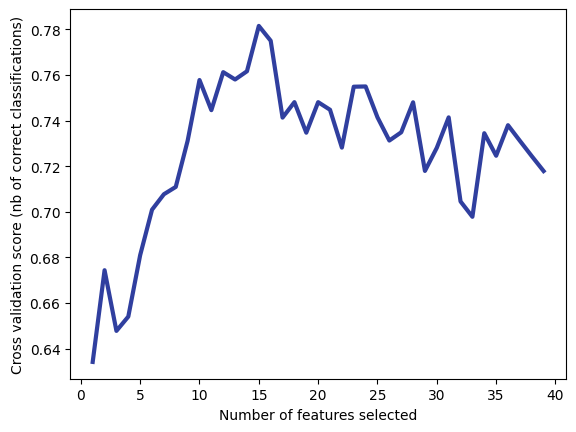

In [ ]:
def do_rfecv(df):
  # Separate features and target
  X = df.drop('Attrition', axis=1)
  y = df['Attrition']

  # Create the RFE object with cross-validation
  rfecv = RFECV(estimator=RandomForestClassifier(random_state=42), step=1, cv=StratifiedKFold(5), scoring='accuracy')

  # Fit RFECV to the data
  rfecv.fit(X, y)

  # Print the optimal number of features
  print("Optimal number of features : %d" % rfecv.n_features_)

  # Print the selected features
  selected_features = X.columns[rfecv.support_]
  print("Selected features:", selected_features)

  # Plot number of features VS. cross-validation scores
  plt.figure()
  plt.xlabel("Number of features selected")
  plt.ylabel("Cross validation score (nb of correct classifications)")
  #plt.plot(range(1, len(rfecv.grid_scores) + 1), rfecv.grid_scores_)
  plt.plot(range(1, len(rfecv.cv_results_['mean_test_score']) + 1), rfecv.cv_results_['mean_test_score'], color='#303F9F', linewidth=3)
  plt.show()

  return selected_features

selected_features = do_rfecv(df)

In [ ]:
features_from_rfecv = ['Age', 'Years_Experience', 'Years_experience_lastorganization',
       'JobTitle', 'Allowances', 'Payment_Overtime',
       'Training_programs_During_last_three_years', 'Job_Support',
       'Emotional_Commitment', 'Distance_to_work', 'Work_Live_Balance',
       'Physical_Stress', 'Psychological_Exhaustion', 'Job_Stability',
       'Job_Opportunities']

In [ ]:
features_in_df = set(df.columns)
features_not_in_rfecv = features_in_df - set(features_from_rfecv)
features_not_in_rfecv

{'Academic_degree',
 'Attrition',
 'Bonus',
 'Business_Travel',
 'Department_Administration',
 'Department_Customer Service',
 'Department_Other',
 'Department_Patient Affairs',
 'Department_Processes',
 'Department_Sales',
 'Department_Teaching',
 'Environment_Satisfaction',
 'Gender',
 'Get_Deserved_Promotion',
 'Health_Issues',
 'Job_Engagement',
 'Job_Satisfaction',
 'Maritalstatus_Married',
 'Maritalstatus_Single',
 'MedicalInsurance',
 'MonthlySalary',
 'OverTime',
 'Recognition',
 'Rewards_Wages_Satisfaction',
 'Useful_Training_Programs'}

In [ ]:
# Extract feature names from less_significant_features_chi2
less_significant_chi2_features = less_significant_features_chi2['Feature'].tolist()

# Convert features_not_in_rfecv (which is a set) to a list
features_not_in_rfecv_list = list(features_not_in_rfecv)

# Combine all feature lists into a single list
all_features = zero_mi_features + less_significant_chi2_features + features_not_in_rfecv_list

# Count the occurrences of each feature
from collections import Counter
feature_counts = Counter(all_features)

# Identify features that appear in at least two of the lists
columns_to_remove_based_on_overlap = [feature for feature, count in feature_counts.items() if count >= 2 and feature != 'Attrition']

print("Columns to be removed based on overlap:")
print(columns_to_remove_based_on_overlap)

Columns to be removed based on overlap:
['Gender', 'Academic_degree', 'OverTime', 'MedicalInsurance', 'Rewards_Wages_Satisfaction', 'Work_Live_Balance', 'Useful_Training_Programs', 'Business_Travel', 'Health_Issues', 'Environment_Satisfaction', 'Department_Administration', 'Department_Processes', 'Department_Sales', 'Maritalstatus_Married', 'Maritalstatus_Single', 'Department_Customer Service']


In [ ]:
# Drop the identified columns from the DataFrame
if 'OverTime' in columns_to_remove_based_on_overlap:
    columns_to_remove_based_on_overlap.remove('OverTime')
columns_to_remove_based_on_overlap.append('Years_Experience')
columns_to_remove_based_on_overlap.append('Years_experience_lastorganization')
df = df.drop(columns=columns_to_remove_based_on_overlap, errors='ignore')

print(f"DataFrame shape after removing overlapping columns: {df.shape}")
display(df.shape)

DataFrame shape after removing overlapping columns: (298, 23)


(298, 23)

In [ ]:
df.columns

Index(['Attrition', 'Age', 'JobTitle', 'MonthlySalary', 'Allowances', 'Bonus',
       'OverTime', 'Payment_Overtime', 'Get_Deserved_Promotion',
       'Training_programs_During_last_three_years', 'Job_Support',
       'Recognition', 'Emotional_Commitment', 'Job_Engagement',
       'Distance_to_work', 'Physical_Stress', 'Psychological_Exhaustion',
       'Job_Stability', 'Job_Satisfaction', 'Job_Opportunities',
       'Department_Other', 'Department_Patient Affairs',
       'Department_Teaching'],
      dtype='object')

In [ ]:
def Apply_SMOTE_NC(X, y):
  # Identify the indices of categorical features
  categorical_features = [col for col in X.columns if X[col].nunique() < 5]

  # Apply SMOTENC to the training data
  smote_nc = SMOTENC(categorical_features=categorical_features, random_state=42)
  X_res_smote_nc, y_res_smote_nc = smote_nc.fit_resample(X, y)

  # Check the class distribution after SMOTENC
  print(f"Resampled class distribution (SMOTENC): {Counter(y_res_smote_nc)}")
  #df = pd.concat([X_res_smote_nc, y_res_smote_nc], axis=1)
  return X_res_smote_nc, y_res_smote_nc


def Normalize_data(df):
  columns_to_normalize = [col for col in df.columns if df[col].nunique() > 10]
  # Standardization (Z-score normalization)
  scaler = StandardScaler()
  df[columns_to_normalize] = scaler.fit_transform(df[columns_to_normalize])
  return df

In [ ]:
target_column_name = "Attrition"

# Separate features (X) and target (y)
X_all = df.drop(columns=[target_column_name]).values
y_all = df[target_column_name].values
feature_names = df.drop(columns=[target_column_name]).columns.tolist()

# Determine class names (assuming binary classification)
unique_classes = np.unique(y_all)
class_names = [f"Class {c}" for c in unique_classes]

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, stratify=y_all, random_state=42
)

# Convert X_train and X_test to DataFrames for SMOTE-NC and Normalization
X_train_df = pd.DataFrame(X_train, columns=feature_names)
X_test_df = pd.DataFrame(X_test, columns=feature_names)

# Apply SMOTE-NC to training data
print("Applying SMOTE-NC to training data...")
X_train_res_df, y_train_res = Apply_SMOTE_NC(X_train_df, y_train)

# Identify columns to normalize (numerical columns with more than 10 unique values)
columns_to_normalize = [col for col in X_train_res_df.columns if X_train_res_df[col].nunique() > 10]

# Initialize and fit StandardScaler on the resampled training data
scaler = StandardScaler()
X_train_res_df[columns_to_normalize] = scaler.fit_transform(X_train_res_df[columns_to_normalize])

# Transform the test data using the *same* scaler fitted on the training data
X_test_df[columns_to_normalize] = scaler.transform(X_test_df[columns_to_normalize])

# Convert processed DataFrames back to NumPy arrays for model training
X_train_processed = X_train_res_df.values
X_test_processed = X_test_df.values

model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_processed, y_train_res)
y_pred = model.predict(X_test_processed)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

print(classification_report(y_test, y_pred))

Applying SMOTE-NC to training data...
Resampled class distribution (SMOTENC): Counter({np.int64(1): 153, np.int64(0): 153})
              precision    recall  f1-score   support

           0       0.76      0.82      0.78        38
           1       0.63      0.55      0.59        22

    accuracy                           0.72        60
   macro avg       0.69      0.68      0.69        60
weighted avg       0.71      0.72      0.71        60



In [ ]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 7.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=9fdfbda46e2634f697bb2bfd74f4b6abb11b53dc97c977547085f4d88f73229c
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime
ERROR: Operation cancelled by user


In [ ]:
from lime import lime_tabular

# Create a LimeTabularExplainer object
explainer = lime_tabular.LimeTabularExplainer(
    X_train_processed,
    feature_names=X_train_res_smote_nc_df.columns.tolist(),
    class_names=['No Attrition', 'Attrition'],
    mode='classification'
)

ModuleNotFoundError: No module named 'lime'

In [ ]:
count = 0
no_attrition_indx = []
for instance_idx in range(len(X_test_final)): # Changed range(337) to range(len(X_test_df))
  # Also, X_test_df.iloc[instance_idx].values[-1] is checking the last feature, not the target.
  # Assuming you want to filter based on the actual y_test values or predictions
  # For now, I will assume the intention was to iterate over the test set.

  # To get predictions for X_test_df, you would typically use model.predict(X_test_df.iloc[instance_idx].values.reshape(1, -1))
  # or filter by actual y_test values for evaluation.

  # If the goal is to explain instances where the TRUE label (from y_test) is 1 (Attrition)
  if y_test_final.iloc[instance_idx] == 1: # Assuming y_test corresponds to X_test_df rows
    count += 1
    no_attrition_indx.append(instance_idx)
    explanation = explainer.explain_instance(
    X_test_final.iloc[instance_idx].values,
      model.predict_proba,
      num_features=10
    )
    # Display the explanation
    explanation.show_in_notebook()
    if count == 5:
      break

In [ ]:
lime_ft_counter = []
def get_top_features(explanation, num_features=10):
    """
    Extracts the top feature names and their importance scores from a LIME explanation.
    """
    top_features = explanation.as_list()
    top_features = top_features[:num_features]
    feature_names = [feature[0] for feature in top_features]
    feature_importances = [feature[1] for feature in top_features]

    return feature_names, feature_importances

count = 0
attrition_idx = []
for instance_idx in range(len(X_test_final)):
  if y_test_final.iloc[instance_idx] == 1.0 and y_pred_new[instance_idx] == 1.0:
    count += 1
    attrition_idx.append(instance_idx)
    explanation = explainer.explain_instance(
      X_test_final.iloc[instance_idx].values,
      model.predict_proba,
      num_features=10
    )
    # Display the explanation
    ##explanation.show_in_notebook()
    feature_names, feature_importances = get_top_features(explanation)
    #print(f"Top Features: {feature_names}")
    for feature in feature_names:
      lime_ft_counter.append(feature)
    #print(f"Importances: {feature_importances}")
    #if count == 5:
      #break

In [ ]:
# Count the frequency of each team
team_counts = Counter(lime_ft_counter)

# Sort teams by counts in descending order
sorted_teams = sorted(team_counts.items(), key=lambda item: item[1], reverse=True)

# Extract sorted team names and counts
teams = [team for team, count in sorted_teams]
counts = [count for team, count in sorted_teams]

# Print the sorted teams and their counts
temp = 0
for team, count in sorted_teams:
    print(f"{team}: {count}")
    #temp += 1
    #if(temp == 20):
    #  break

In [ ]:
!pip install shap

In [ ]:
from scipy.special import softmax
import shap

shap_values_array = []

# for model in best_models:
# Fits the explainer
explainer = shap.Explainer(model.predict, X_test_processed, feature_names=X_test_final.columns.tolist())
shap_values = explainer(X_test_processed)
shap_values_array.append(shap_values)

In [ ]:
len(shap_values_array[0])

In [ ]:
def print_feature_importances_shap_values(shap_values, features):
    '''
    Prints the feature importances based on SHAP values in an ordered way
    shap_values -> The SHAP values calculated from a shap.Explainer object
    features -> The name of the features, on the order presented to the explainer
    '''
    # Calculates the feature importance (mean absolute shap value) for each feature
    importances = []
    for i in range(shap_values.values.shape[1]):
        importances.append(np.mean(np.abs(shap_values.values[:, i])))
    # Calculates the normalized version
    importances_norm = softmax(importances)
    # Organize the importances and columns in a dictionary
    feature_importances = {fea: imp for imp, fea in zip(importances, features)}
    feature_importances_norm = {fea: imp for imp, fea in zip(importances_norm, features)}
    # Sorts the dictionary
    feature_importances = {k: v for k, v in sorted(feature_importances.items(), key=lambda item: item[1], reverse = True)}
    feature_importances_norm= {k: v for k, v in sorted(feature_importances_norm.items(), key=lambda item: item[1], reverse = True)}
    # Prints the feature importances
    for k, v in feature_importances.items():
        print(f"{k} -> {v:.4f} (softmax = {feature_importances_norm[k]:.4f})")

In [ ]:
print_feature_importances_shap_values(shap_values_array[0], X_test_final.columns)
shap.plots.bar(shap_values_array[0])

In [ ]:
reshaped_arr = shap_values_array[0].values.reshape(len(shap_values_array[0]), len(X_test_final.columns))
reshaped_arr.shape

# Create an Explanation object
explanation = shap.Explanation(
    values=reshaped_arr, #values is the shap values
    #base_values=X_test_tensor, #Replace with actual base values, or calculate manually if necessary
    data=X_test_processed, #Data used to create shap values
    feature_names=X_test_final.columns
)

# Now 'explanation' is a shap.Explanation object, not a numpy array
print(type(explanation))

In [ ]:
!pip install dice-ml

In [ ]:
for column in df.columns:
  print(f"Column '{column}': {df[column].nunique()} unique values")

In [ ]:
continuous_features = [col for col in df.columns if df[col].nunique() > 8]

In [ ]:
import dice_ml
# Dataset
data_dice = dice_ml.Data(dataframe=pd.concat([X_train_res_smote_nc_df, pd.Series(y_train_combined, name='Attrition')], axis=1),
                         continuous_features=continuous_features,
                         outcome_name='Attrition')

## For best Shallow Model
rf_dice = dice_ml.Model(model=model,
                        # There exist backends for tf, torch, ...
                        backend="sklearn")
explainer = dice_ml.Dice(data_dice,
                         rf_dice,
                         # Random sampling, genetic algorithm, kd-tree,...
                         method="random")

# Generate CF based on the blackbox model
input_datapoint = X_test_final[1:2]
cf = explainer.generate_counterfactuals(input_datapoint,
                                  total_CFs=3,
                                  desired_class="opposite")

# Visualize it
cf.visualize_as_dataframe(show_only_changes=True)

In [ ]:
df.columns

In [ ]:
# Create feasible (conditional) Counterfactuals
# features_to_vary=['BusinessTravel', 'DailyRate', 'DistanceFromHome',
#        'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement',
#        'JobLevel', 'JobSatisfaction', 'MonthlyRate',
#        'OverTime', 'PercentSalaryHike',
#        'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany',
#        'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
features_to_vary=['BusinessTravel',
                  'DailyRate',
                  'EnvironmentSatisfaction',
                  'HourlyRate',
                  'JobInvolvement',
                  'JobLevel',
                  'JobSatisfaction',
                  'MonthlyRate',
                  'OverTime',
                  # 'Shift',
                  'TrainingTimesLastYear',
                  'WorkLifeBalance',
                  # 'YearsWithCurrManager'
                  ]
#permitted_range={'BusinessTravel_Travel_Frequently':[1,5],
#                'TrainingTimesLastYear':[0, 30]}
# Now generating explanations using the new feature weights
cf = explainer.generate_counterfactuals(input_datapoint,
                                  total_CFs=3,
                                  desired_class="opposite",
                                  #permitted_range=permitted_range,
                                  features_to_vary=features_to_vary)
# Visualize it
cf.visualize_as_dataframe(show_only_changes=True)

In [ ]:
global_changable_cols = []
y_test_series = pd.Series(y_test_final)
y_pred_series = pd.Series(y_pred_new)

for j in range(len(X_test_final)):
  if y_test_series.iloc[j] == 0.0 or y_test_series.iloc[j] != y_pred_series.iloc[j]: # if not attrition or if it is not predicted correctly, we do not need to consider
    continue
  input_datapoint = X_test_final.iloc[j:j+1]
  # Try to make features_to_vary less restrictive to find counterfactuals
  try:
    cf = explainer.generate_counterfactuals(input_datapoint,
                                          total_CFs=3,
                                          desired_class="opposite",
                                          features_to_vary = features_to_vary) # Changed features_to_vary to "all" to allow all features to vary
  except:
    continue
  if cf.cf_examples_list and cf.cf_examples_list[0].final_cfs_df is not None and not cf.cf_examples_list[0].final_cfs_df.empty:
    cf_df = cf.cf_examples_list[0].final_cfs_df
    if 'Attrition' in cf_df.columns:
      cf_df.drop('Attrition', axis=1, inplace=True)
    cf_df_numpy = cf_df.to_numpy()

    for i in range(len(cf_df)):
      row = cf_df.iloc[i]
      changable_cols = []
      for col in row.index:
        if(col in input_datapoint.columns and row[col] != input_datapoint[col].values[0]):
          additional = ""
          if(row[col] > input_datapoint[col].values[0]):
            additional = "[inc]"
          else:
            additional = "[dec]"
          changable_cols.append(col+additional)
      if changable_cols: # Only append if there are actual changes
        global_changable_cols.append(changable_cols)
  else:
    print(f"No counterfactuals found for instance {j}")


# Flatten the list of lists
all_teams = [team for team in global_changable_cols]

all_teams_as_str = [', '.join(team) for team in all_teams]

# Count the frequency of each team
team_counts = Counter(team for team in all_teams_as_str)

# Extract the team names and counts for plotting
teams = list(team_counts.keys())
counts = list(team_counts.values())

# Create the bar plot
plt.figure(figsize=(20, 10))
plt.barh(teams, counts) # Use barh for horizontal bar plot
plt.ylabel("Features") # Y-axis now represents features
plt.xlabel("Frequency") # X-axis now represents frequency
plt.title("Frequency of Features Changed for Counterfactuals")
# plt.xticks(rotation=90) # No need to rotate x-axis labels for horizontal bar plot
plt.tight_layout() # Adjust layout
plt.show()

In [ ]:
# df_watson = pd.read_csv('/content/WA_Fn-UseC_-HR-Employee-Attrition.csv')
# df_watson.head()

In [ ]:
# df_watson_healthcare = df_watson[
#     (df_watson['JobRole'] == 'Healthcare Representative') |
#     ((df_watson['JobRole'] == 'Laboratory Technician') & (df_watson['EducationField'] == 'Medical')) |
#     ((df_watson['JobRole'] == 'Research Scientist') & (df_watson['EducationField'] == 'Medical'))
# ]

# print("Filtered DataFrame based on healthcare-related roles and education:")
# display(df_watson_healthcare.head())
# display(df_watson_healthcare.shape)

In [ ]:
# attrition_ratio = df_watson_healthcare['Attrition'].value_counts(normalize=True)
# print("Attrition Ratio (Yes/No):")
# print(attrition_ratio)

In [ ]:
df_train = pd.read_csv('/content/df_encoded_dropped_outlhandled_new.csv')
df_train.head()

In [ ]:
df = df_watson_healthcare.copy()

In [ ]:
# removing columns with static value (similar value for all) and primary key value
cols_to_remove = [col for col in df.columns if df[col].nunique() == 1]
print("Columns to remove due to having static value:")
print(cols_to_remove)
df = df.drop(columns=cols_to_remove)

In [ ]:
cols_to_encode = [col for col in df.columns if df[col].dtype == 'object']
print("Columns that may need encoding:")
print(cols_to_encode)

In [ ]:
# Map Attrition to 1 and 0
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

# Map BusinessTravel to ordinal values
business_travel_mapping = {'Non-Travel': 0, 'Travel_Rarely': 1, 'Travel_Frequently': 2}
df['BusinessTravel'] = df['BusinessTravel'].map(business_travel_mapping)

# Map Gender to 1 and 0
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})

# Map OverTime to 1 and 0
df['OverTime'] = df['OverTime'].map({'Yes': 1, 'No': 0})

In [ ]:
df['EducationField'].value_counts()

In [ ]:
# Perform one-hot encoding for the remaining categorical columns
df = pd.get_dummies(df, columns=['EducationField', 'JobRole', 'MaritalStatus'], drop_first=True).replace({True: 1, False: 0})

In [ ]:
df.head(3)

In [ ]:
df = df.drop(columns=['EmployeeNumber', 'Gender', 'MonthlyIncome'])

In [ ]:
display(df.columns)

In [ ]:
display(df_train.columns)

In [ ]:
df_cols = set(df.columns)
df_train_cols = set(df_train.columns)

# Columns in df but not in df_train
columns_only_in_df = df_cols - df_train_cols
print("Columns present in 'df' but not in 'df_train':")
print(columns_only_in_df)

print("\n" + "-"*50 + "\n")

# Columns in df_train but not in df
columns_only_in_df_train = df_train_cols - df_cols
print("Columns present in 'df_train' but not in 'df':")
print(columns_only_in_df_train)

In [ ]:
common_columns = list(set(df.columns) & set(df_train.columns))

df_common = df[common_columns].copy()
df_train_common = df_train[common_columns].copy()

print(f"Number of common columns: {len(common_columns)}")
print("Common columns:", common_columns)

print("\nFirst 5 rows of df_common:")
display(df_common.head())

print("\nFirst 5 rows of df_train_common:")
display(df_train_common.head())

In [ ]:
for column in df_common.columns:
  df_common[column] = df_common[column].astype(float)
df_common.head(3)

In [ ]:
def Apply_SMOTE_NC(X, y):
  # Identify the indices of categorical features
  categorical_features = [col for col in X.columns if X[col].nunique() < 5]

  # Apply SMOTENC to the training data
  smote_nc = SMOTENC(categorical_features=categorical_features, random_state=42)
  X_res_smote_nc, y_res_smote_nc = smote_nc.fit_resample(X, y)

  # Check the class distribution after SMOTENC
  print(f"Resampled class distribution (SMOTENC): {Counter(y_res_smote_nc)}")
  return X_res_smote_nc, y_res_smote_nc


# Prepare data for SMOTE-NC and Normalization
target_column_name = "Attrition"

# 1. Data from df_train_common (external dataset)
X_df_train_common = df_train_common.drop(columns=[target_column_name])
y_df_train_common = df_train_common[target_column_name]

# 2. Split df_common (processed Watson healthcare data) 50/50 for additional training and testing
X_df_common_full = df_common.drop(columns=[target_column_name])
y_df_common_full = df_common[target_column_name]

X_common_half_train, X_common_half_test, y_common_half_train, y_common_half_test = train_test_split(
    X_df_common_full, y_df_common_full, test_size=0.5, stratify=y_df_common_full, random_state=42
)

# 3. Combine df_train_common and half of df_common for the new training set
X_train_combined = pd.concat([X_df_train_common, X_common_half_train], ignore_index=True)
y_train_combined = pd.concat([y_df_train_common, y_common_half_train], ignore_index=True)

# 4. The other half of df_common will be the new test set
X_test_final = X_common_half_test
y_test_final = y_common_half_test

# Apply SMOTE-NC to the combined training data
print("Applying SMOTE-NC to combined training data...")
X_train_res_smote_nc_df, y_train_res_smote_nc = Apply_SMOTE_NC(X_train_combined, y_train_combined)

# Identify columns to normalize (numerical columns with more than 2 unique values) from the resampled training data
columns_to_normalize = [col for col in X_train_res_smote_nc_df.columns if X_train_res_smote_nc_df[col].nunique() > 10]

# Initialize and fit MinMaxScaler on the resampled training data
from sklearn.preprocessing import MinMaxScaler
scaler = StandardScaler()
X_train_res_smote_nc_df[columns_to_normalize] = scaler.fit_transform(X_train_res_smote_nc_df[columns_to_normalize])

# Transform the final test data using the *same* scaler fitted on the training data
X_test_final[columns_to_normalize] = scaler.transform(X_test_final[columns_to_normalize])

# Convert processed DataFrames back to NumPy arrays for model training (if needed, or keep as DataFrame for consistency)
X_train_processed = X_train_res_smote_nc_df.values
X_test_processed = X_test_final.values

# Train a Logistic Regression model
model = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
model.fit(X_train_processed, y_train_res_smote_nc)

# Make predictions on the processed test data
y_pred_new = model.predict(X_test_processed)

# Evaluate the model
print("\nClassification Report on new test data:")
print(classification_report(y_test_final, y_pred_new))

In [ ]:
# Get prediction probabilities for the positive class (class 1)
y_pred_proba = model.predict_proba(X_test_final)[:, 1]

# Define a custom threshold (e.g., 0.3 instead of the default 0.5)
custom_threshold = 0.5

# Apply the custom threshold to get new predictions
y_pred_custom_threshold = (y_pred_proba >= custom_threshold).astype(int)

# Evaluate the model with the custom threshold
print(f"\nClassification Report on df_common with custom threshold ({custom_threshold}):")
print(classification_report(y_test_final, y_pred_custom_threshold))

You can experiment with different `custom_threshold` values in the cell above to see how they impact the precision and recall for the 'Attrition' class (class 1).

In [ ]:
import numpy as np

# Flatten the list of lists (each inner list represents features changed for one set of counterfactuals)
all_teams_flat_lists = global_changable_cols

# Number of bootstrap samples
n_bootstraps = 1000
# Confidence level for intervals
confidence_level = 0.95

bootstrapped_counts = {} # To store counts for each feature across bootstrap samples

for _ in range(n_bootstraps):
    # Resample the list of lists with replacement
    resampled_lists_indices = np.random.choice(len(all_teams_flat_lists), size=len(all_teams_flat_lists), replace=True)
    resampled_lists = [all_teams_flat_lists[i] for i in resampled_lists_indices]

    # Flatten the resampled lists into a single list of features
    current_bootstrap_features = [feature for sublist in resampled_lists for feature in sublist]

    # Count frequencies for the current bootstrap sample
    current_counts = Counter(current_bootstrap_features)

    # Store these counts
    for feature, count in current_counts.items():
        if feature not in bootstrapped_counts:
            bootstrapped_counts[feature] = []
        bootstrapped_counts[feature].append(count)

# Calculate mean and confidence intervals for each feature
feature_stats = []
for feature, counts_list in bootstrapped_counts.items():
    if len(counts_list) >= 2: # Ensure enough data to calculate CI
        mean_count = np.mean(counts_list)
        # Calculate the lower and upper percentile for the confidence interval
        lower_bound = np.percentile(counts_list, (1 - confidence_level) / 2 * 100)
        upper_bound = np.percentile(counts_list, (1 + confidence_level) / 2 * 100)

        feature_stats.append({
            'Feature': feature,
            'Mean_Frequency': mean_count,
            'Lower_CI': lower_bound,
            'Upper_CI': upper_bound
        })

# Convert to DataFrame and sort by mean frequency
feature_stats_df = pd.DataFrame(feature_stats).sort_values(by='Mean_Frequency', ascending=False)

# Filter to include only features with mean frequency >= 2
feature_stats_df = feature_stats_df[feature_stats_df['Mean_Frequency'] >= 2]

# Prepare data for plotting
teams = feature_stats_df['Feature'].tolist()
mean_counts = feature_stats_df['Mean_Frequency'].tolist()
lower_ci = feature_stats_df['Lower_CI'].tolist()
upper_ci = feature_stats_df['Upper_CI'].tolist()

# Calculate error bars
error_bars = [mean_counts[i] - lower_ci[i] for i in range(len(mean_counts))]

# Create the bar plot with confidence intervals
plt.figure(figsize=(20, 10))
plt.barh(teams, mean_counts, xerr=error_bars, capsize=5, color='skyblue')
plt.ylabel("Features")
plt.xlabel(f"Mean Frequency (with {int(confidence_level * 100)}% Confidence Interval)")
plt.title("Mean Frequency of Features Changed for Counterfactuals (Bootstrapped)")
plt.tight_layout()
plt.show()